# Task 2 Sentiment and Thematic Analysis Validation Notebook

### 1. Tool Selection Rationale
We deploy `distilbert-base-uncased-finetuned-sst-2-english` via Hugging Face pipelines for the production run. While VADER offers latency advantages during local prototyping, DistilBERT utilizes rich contextual embeddings that improve classification accuracy on complex syntactic structures, local banking terms, and layered app complaints. 

### 2. Thematic Grouping Logic
Keywords and structural n-grams are validated via a `TfidfVectorizer` to locate statistical feedback patterns. Extracted tokens are programmatically channeled into 4 core business-relevant themes:
* **Account Access Issues**: Driven by terms matching authentication, PIN errors, and login lockouts.
* **Transaction Performance**: Driven by terms matching timeouts, transfer speeds, and transaction failures.
* **UI & Design**: Driven by layout, aesthetics, loading screens, and visual responsiveness.
* **Customer Support**: Maps to branch tickets, agent communication, and service disputes.


In [ ]:
import os
import shutil

# Check standard user and virtual environment directories
potential_paths = [
    os.path.expanduser('~/nltk_data/corpora'),
    os.path.expanduser('~/venv/nltk_data/corpora'),
    os.path.expanduser('~/venv/share/nltk_data/corpora')
]

targets = ['stopwords', 'wordnet', 'omw-1.4']

for base_path in potential_paths:
    if os.path.exists(base_path):
        for target in targets:
            zip_file = os.path.join(base_path, f"{target}.zip")
            folder_path = os.path.join(base_path, target)
            
            if os.path.exists(zip_file):
                os.remove(zip_file)
                print(f"Removed: {zip_file}")
            if os.path.exists(folder_path):
                shutil.rmtree(folder_path)
                print(f"Removed: {folder_path}")


In [1]:
import os
import sys
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer


# ------------------------------------------------------------
# CONFIGURE MODULE IMPORTS
# ------------------------------------------------------------

sys.path.append(os.path.abspath('../src'))

from text_cleaner import clean_review_text
from sentiment_analyzer import compute_sentiment_batch
from thematic_analyzer import map_text_to_business_theme


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

input_file = '../data/raw/cleaned_reviews.csv'

df = pd.read_csv(input_file)

print(f"Loaded {len(df)} reviews.")


Loaded 8807 reviews.


In [7]:
df['review_id'] = [f"rev_{i}" for i in range(len(df))]

# ------------------------------------------------------------
# TEXT CLEANING
# ------------------------------------------------------------

print("\nCleaning review text...")

df['cleaned_text'] = (
    df['review']
    .astype(str)
    .apply(clean_review_text)
)
print("\nAssigning business themes...")

df['identified_theme'] = df['cleaned_text'].apply(map_text_to_business_theme)


Cleaning review text...

Assigning business themes...


In [8]:
# ------------------------------------------------------------
# SENTIMENT ANALYSIS
# ------------------------------------------------------------

print("\nRunning DistilBERT sentiment inference...")

labels, scores = compute_sentiment_batch(
    df['review'].astype(str),
    batch_size=64
)

df['sentiment_label'] = labels
df['sentiment_score'] = scores


Running DistilBERT sentiment inference...


In [10]:
# ------------------------------------------------------------
# STAR RATING ANALYSIS
# ------------------------------------------------------------

rating_col = None

if 'rating' in df.columns:
    rating_col = 'rating'

elif 'stars' in df.columns:
    rating_col = 'stars'

if rating_col:

    print("\n=== Mean Sentiment by Rating ===")

    print(
        df.groupby(rating_col)['sentiment_score']
        .mean()
        .round(4)
    )

    print("\n=== Sentiment Distribution by Rating ===")

    print(
        pd.crosstab(
            df[rating_col],
            df['sentiment_label']
        )
    )



=== Mean Sentiment by Rating ===
rating
1    0.9791
2    0.9691
3    0.9687
4    0.9642
5    0.9635
Name: sentiment_score, dtype: float64

=== Sentiment Distribution by Rating ===
sentiment_label  Negative  Neutral  Positive
rating                                      
1                    1683        8       245
2                     365        5        83
3                     423        5       188
4                     376       14       500
5                    1129       60      3723


In [11]:
# ------------------------------------------------------------
# BANK ANALYSIS
# ------------------------------------------------------------

if 'bank' in df.columns:

    print("\n=== Mean Sentiment by Bank ===")

    print(
        df.groupby('bank')['sentiment_score']
        .mean()
        .sort_values(ascending=False)
        .round(4)
    )

    print("\n=== Sentiment Distribution by Bank ===")

    print(
        pd.crosstab(
            df['bank'],
            df['sentiment_label']
        )
    )

    print("\n=== Theme Breakdown by Bank ===")

    print(
        pd.crosstab(
            df['bank'],
            df['identified_theme']
        )
    )



=== Mean Sentiment by Bank ===
bank
Dashen Bank          0.9780
CBE Bank             0.9669
Bank of Abyssinia    0.9642
Name: sentiment_score, dtype: float64

=== Sentiment Distribution by Bank ===
sentiment_label    Negative  Neutral  Positive
bank                                          
Bank of Abyssinia       752        6       461
CBE Bank               2921       84      3715
Dashen Bank             303        2       563

=== Theme Breakdown by Bank ===
identified_theme   Account Access Issues  Customer Support  General Feedback  \
bank                                                                           
Bank of Abyssinia                     66                49               929   
CBE Bank                             191               332              5260   
Dashen Bank                           21                41               660   

identified_theme   Transaction Performance  UI & Design  
bank                                                     
Bank of Abyssini

In [12]:
# ------------------------------------------------------------
# EXPORT FINAL OUTPUT
# ------------------------------------------------------------

output_df = (
    df.rename(columns={'review': 'review_text'})[
        [
            'review_id',
            'review_text',
            'sentiment_label',
            'sentiment_score',
            'identified_theme'
        ]
    ]
)

os.makedirs('../data/processed', exist_ok=True)

output_file = '../data/processed/task2_output.csv'

output_df.to_csv(output_file, index=False)

print(f"\nSaved output to:\n{output_file}")

print("\nSample Output:")
print(output_df.head())


Saved output to:
../data/processed/task2_output.csv

Sample Output:
  review_id         review_text sentiment_label  sentiment_score  \
0     rev_0                Good        Positive           0.9998   
1     rev_1                🤙🏼🤙🏼        Negative           0.6971   
2     rev_2               worst        Negative           0.9998   
3     rev_3  this app very full        Positive           0.9974   
4     rev_4           good apps        Positive           0.9999   

   identified_theme  
0  General Feedback  
1  General Feedback  
2  General Feedback  
3  General Feedback  
4  General Feedback  


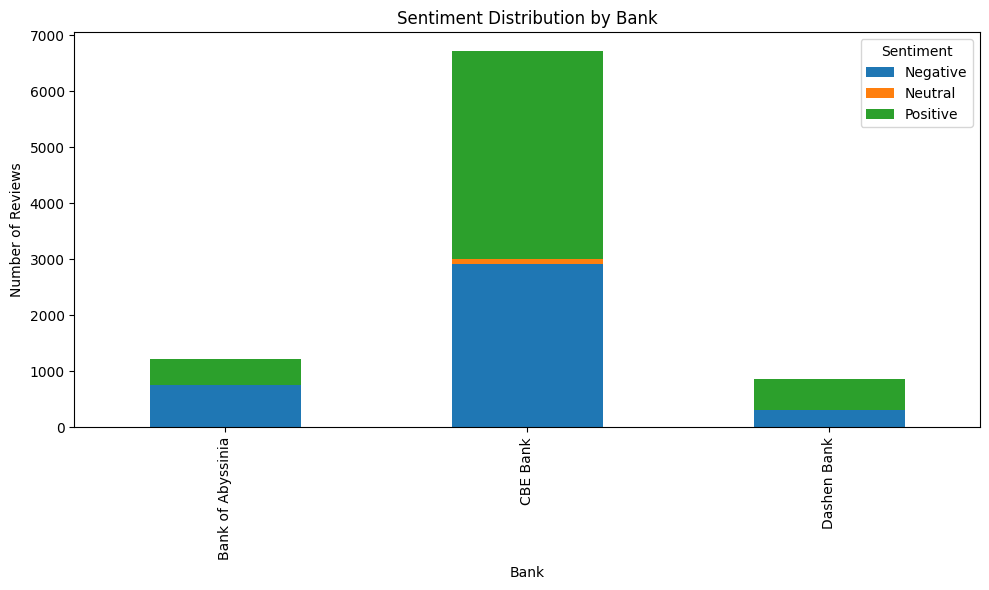

In [13]:
import matplotlib.pyplot as plt

sentiment_by_bank = pd.crosstab(df['bank'], df['sentiment_label'])

sentiment_by_bank.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

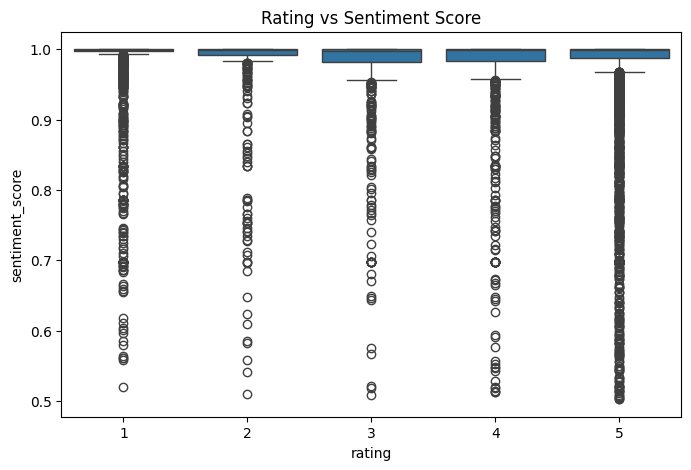

In [14]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x='rating',
    y='sentiment_score',
    data=df
)

plt.title("Rating vs Sentiment Score")
plt.show()

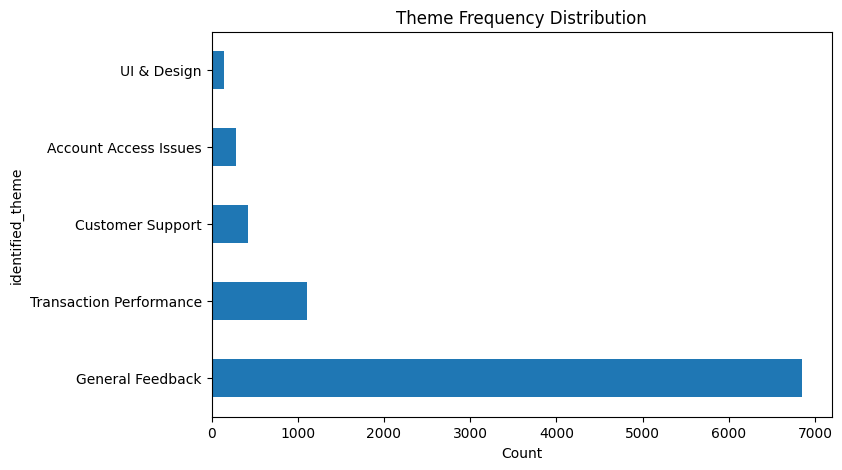

In [15]:
theme_counts = df['identified_theme'].value_counts()

theme_counts.plot(
    kind='barh',
    figsize=(8,5),
    title="Theme Frequency Distribution"
)

plt.xlabel("Count")
plt.show()